# 补充材料

In [1]:
dir =  @__DIR__
dir_of_dir = dirname(@__DIR__)
madeup_path = joinpath(dir, "made_up_file.jl")

@show dir 
@show dir_of_dir
@show madeup_path

dir = "/home/xwc/Documents/optimal-control/code/bilibili/lec0-julia_intro"
dir_of_dir = "/home/xwc/Documents/optimal-control/code/bilibili"
madeup_path = "/home/xwc/Documents/optimal-control/code/bilibili/lec0-julia_intro/made_up_file.jl"


"/home/xwc/Documents/optimal-control/code/bilibili/lec0-julia_intro/made_up_file.jl"

In [2]:
import Pkg 
Pkg.status()

Status `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Project.toml`
  [6e4b80f9] BenchmarkTools v1.3.2
  [f6369f11] ForwardDiff v0.10.35
  [b964fa9f] LaTeXStrings v1.3.0
  [91a5bcdd] Plots v1.38.17
  [438e738f] PyCall v1.96.1


In [3]:
Pkg.activate(@__DIR__)
Pkg.add("BenchmarkTools")

  Activating project at `~/Documents/optimal-control/code/bilibili/lec0-julia_intro`
   Resolving package versions...
  No Changes to `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Project.toml`
  No Changes to `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Manifest.toml`


In [4]:
Pkg.instantiate()

## 基本语法和线性代数

In [5]:
# Julia自带的标准库，与环境无关
# import LinearAlgebra # LinearAlgebra.norm()
# import LinearAlegbra as la # la.norm()
using LinearAlgebra # norm()
using Test

In [6]:
a = 2 
b = 3.4
c = rand()  # uniform [0, 1]
d = randn() # gaussian

@show a 
@show a * b 
@show a ^ 2 
@show a + b; # supress output with ; 

a = 2
a * b = 6.8
a ^ 2 = 4
a + b = 5.4


In [7]:
Ω = 4.5 # "\Omega<tab>"
ẋ = 2.4; # "x\dot<tab>"

In [8]:
# arrays 
vec = [1,2,3,4.0];  # vector, colons or commas work
mat = [1 2; 3 4.0]; # matrix, must use colons between rows

@show vec
@show mat;

vec = [1.0, 2.0, 3.0, 4.0]
mat = [1.0 2.0; 3.0 4.0]


In [9]:
vec[1:2] # indexing starts at 1 

2-element Vector{Float64}:
 1.0
 2.0

In [10]:
mat[:, 2] # all rows, 2nd column 

2-element Vector{Float64}:
 2.0
 4.0

In [11]:
mat[2,1:2] # row 2, columns 1:2 (automatically converts to vector)

2-element Vector{Float64}:
 3.0
 4.0

In [12]:
reshape(mat[2,1:2], 1, 2) # want a matrix?

1×2 Matrix{Float64}:
 3.0  4.0

In [13]:
# edit elements 
vec[3] = 100;
@show vec 

mat[1,1] = 20
@show mat;

vec = [1.0, 2.0, 100.0, 4.0]
mat = [20.0 2.0; 3.0 4.0]


In [14]:
# matrix multiplication
A = randn(2,2)
B = randn(2,2)
C = A * B 
D = A' * A # ' is transpose 

2×2 Matrix{Float64}:
 0.658735  1.04606
 1.04606   1.66572

In [15]:
# matrix vector multiplication 
A = randn(2,2)
b = randn(2)
c = A * b 
d = b' * A 

1×2 adjoint(::Vector{Float64}) with eltype Float64:
 0.698131  -0.298764

In [16]:
size(A)

(2, 2)

In [17]:
size(b)

(2,)

In [18]:
@show identity_2x2 = I(2)
@show zeros(2,2) + I;

identity_2x2 = I(2) = Bool[1 0; 0 1]
zeros(2, 2) + I = [1.0 0.0; 0.0 1.0]


### 线性方程组

In [19]:
# A * x = b 

x = inv(A)*b # bad
x = A\b # good

@test norm(A*x - b) < 1e-10 

Test Passed

In [20]:
# 矩阵分解

A = randn(3,3); A = A'*A + I; # 正定矩阵，可用于所有矩阵分解

# cholesky 最快，只适用于正定矩阵
chol_factor = cholesky(A) # L*L'=A
L = chol_factor.L # 下三角
@test norm(L*L' - A) < 1e-10

## 满秩方阵分解
# QR
qr_factor = qr(A)
Q = qr_factor.Q 
R = qr_factor.R 
@test norm(Q*R - A) < 1e-10

# LU 
lu_factor = lu(A)
L = lu_factor.L 
U = lu_factor.U 
@test norm(L*U - A) < 1e-10 

Test Passed

In [21]:
b = randn(3)

# 矩阵分解求线性方程组的解
x1 = chol_factor\b 
x2 = qr_factor\b 
x3 = lu_factor\b 

@test norm(x1 - x2) < 1e-10 
@test norm(x1 - x3) < 1e-10 

Test Passed

In [22]:
# ranges
idx = 0:2:10                   # unit range
idx = range(0, 10, step = 2)   # same as above 
idx = range(0, 10, length = 6) # same as above 

0.0:2.0:10.0

## 函数和数据类型

In [23]:
# for loops 
for i = 1:2
    println("here is println output: ",i) # print line 
    @show i 
end

here is println output: 1
i = 1
here is println output: 2
i = 2


In [24]:
# basic type information:
a = randn(2)::Vector{Float64}
@show typeof(a)
@show eltype(a);

typeof(a) = Vector{Float64}
eltype(a) = Float64


In [25]:
b = [1, 3]
@show typeof(b)
@show eltype(b);

typeof(b) = Vector{Int64}
eltype(b) = Int64


In [26]:
# some other types you will see 
A = randn(2,2)::Matrix{Float64} # type assertion
B = [1 0; 0 3]::Matrix{Int64}
a = 4.3::Float64;

In [27]:
randn(2,2)::Matrix{Int64} # fail: randn -> Float64 != Int64

LoadError: TypeError: in typeassert, expected Matrix{Int64}, got a value of type Matrix{Float64}

In [28]:
# list comprehension (like python)
x = [i for i = 1:3]

3-element Vector{Int64}:
 1
 2
 3

In [29]:
# vectors of vectors 
X = [randn(2) for i = 1:3]

3-element Vector{Vector{Float64}}:
 [-0.39054790444046017, -0.9979904745735376]
 [0.5932215576588151, -0.37228487405043426]
 [1.7110420131939192, -1.1369590736290696]

In [30]:
# convert a vector of vectors to a matrix
X_matrix = hcat(X...) # this is the same as hcat(X[1],X[2],X[3])

2×3 Matrix{Float64}:
 -0.390548   0.593222   1.71104
 -0.99799   -0.372285  -1.13696

In [31]:
# vectors of matrices 
X = [randn(2,2) for i = 1:3]

3-element Vector{Matrix{Float64}}:
 [0.5982948506122453 0.054006451737322866; -0.8231097092794525 0.2628790387882388]
 [0.4517508468057881 -0.383292535354508; -1.3352599206095865 -0.21598759757216812]
 [0.2222105199545158 -0.6378186662963697; -1.7180325673152124 0.4114574747233073]

In [32]:
hcat(X...)

2×6 Matrix{Float64}:
  0.598295  0.0540065   0.451751  -0.383293   0.222211  -0.637819
 -0.82311   0.262879   -1.33526   -0.215988  -1.71803    0.411457

In [33]:
function f(x, b) 
    return b*x 
end

output = f(randn(3), 2.4)

3-element Vector{Float64}:
 -1.9757198288375353
  2.14664252887564
  2.3306297053924663

In [34]:
# type assertion of the inputs and outputs to a function
function f2(x::Vector, b::Float64)::Matrix
    # input:
    #     x - a vector (can be a vector of anything)
    #     b - a float 
    # output:
    #     matrix (of anything)
    return b * x * x'
end

output = f2(randn(3), 2.4)

3×3 Matrix{Float64}:
  0.023364   -0.0884399   0.13519
 -0.0884399   0.334772   -0.511735
  0.13519    -0.511735    0.782241

In [35]:
# 1. avoid bugs by specifying the types we expect 
# 2. multiple dispatch

function print_my_type(a::Float64)
    println("thanks for inputting a ~float~")
end
print_my_type(3.4)

thanks for inputting a ~float~


In [36]:
# error
print_my_type(3)

LoadError: MethodError: no method matching print_my_type(::Int64)

[0mClosest candidates are:
[0m  print_my_type([91m::Float64[39m)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[35]:4[24m[39m


In [37]:
function print_my_type(a::Int64)
    println("thanks for inputting an ~integer~")
end
print_my_type(3)

# 相同的函数名，不同的输入类型

thanks for inputting an ~integer~


## 全局变量和局部变量

In [38]:
# 到目前为止所有代码都发生在全局作用域
x = 4.6 

function myf()
    println("i'm printing x, even though it wasn't passed in")
    print("x: ",x)
end

myf()

i'm printing x, even though it wasn't passed in
x: 4.6

In [39]:
# 全局变量有很多负面作用，尽量不要用全局变量，除非是常量 const，这样就无所谓了

const x_const = 4.3

4.3

In [40]:
function test_local_scope()
    # 因为函数没有参数，所以它只能看到全局变量
    println("here is global_var: ", global_var)
    println("here is local_var: ", local_var) # fail 
end

# global variable 
const global_var = 23

let 
    # local variable 
    local_var = 45 
    test_local_scope()
end

here is global_var: 23


LoadError: UndefVarError: `local_var` not defined

In [41]:
# 全局变量的例子
x = 3.4 
function f1()
    if @isdefined(x)
        println("yeah I know about x")
        println("x: ", x)
    end
end
f1()

yeah I know about x
x: 3.4


In [42]:
# 函数能对输入的参数做in-place的修改
# MATLAB不行，但Python可以 
function mutating_function!(input::Vector)
    input[2] = 140
    return nothing
end

let 
    input = [5,9]
    println("input before: ", input)
    
    mutating_function!(input)
    
    println("input after: ", input)
end

input before: [5, 9]
input after: [5, 140]


In [43]:
# 像这样的函数，约定俗成在函数名末尾加一个感叹号!
x = [4, 1, 3, 2]
println("here is x: x = ", x)
println("here is the sorted version of x: ", sort(x))
println("but x is unchanged: x = ", x) 

sort!(x) # ! 说明会修改输入
println("here is the modified x (it's sorted now): x = ", x)

here is x: x = [4, 1, 3, 2]
here is the sorted version of x: [1, 2, 3, 4]
but x is unchanged: x = [4, 1, 3, 2]
here is the modified x (it's sorted now): x = [1, 2, 3, 4]


In [44]:
# 对数组做元素级操作
@show abs(3)
x = randn(4)
@show x
@show abs.(x)
X = randn(2,2)
@show X 
@show abs.(X);

abs(3) = 3
x = [1.6417031315365143, -0.38563256321208483, -0.6518368116437275, -0.562225099360201]
abs.(x) = [1.6417031315365143, 0.38563256321208483, 0.6518368116437275, 0.562225099360201]
X = [0.3306841315929276 -4.414076987170363; -0.018193643049952014 0.9321038260108314]
abs.(X) = [0.3306841315929276 4.414076987170363; 0.018193643049952014 0.9321038260108314]


In [45]:
# vector of vectors 
X = [randn(2) for i = 1:3]

@show X
@show norm.(X);

X = [[0.42378900038544803, -0.28184365465612393], [-0.9040442937127304, -1.738698666963968], [-0.003133371127543829, -1.1070895994303236]]
norm.(X) = [0.5089528097158103, 1.9596859798184065, 1.107094033576831]


## 画图

In [46]:
Pkg.add("Plots")

   Resolving package versions...
  No Changes to `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Project.toml`
  No Changes to `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Manifest.toml`


[ Info: Precompiling IJuliaExt [2f4121a4-3b3a-5ce6-9c5e-1f2673ce168a]


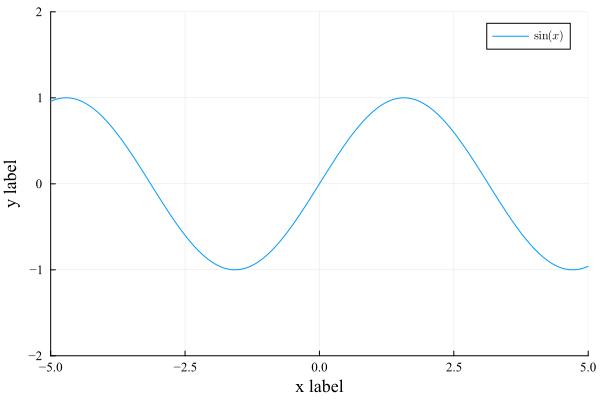

In [47]:
# I like LaTeX Strings
using LaTeXStrings

# plotting 
using Plots  # Pkg.add if needed

# our first plot is just a normal one 
x = -10:.001:10 
plot(x, sin.(x), label = L"\sin(x)", xlabel = "x label",
     ylabel = "y label", xlim = (-5,5), ylim = (-2, 2), fontfamily="Times New Roman")

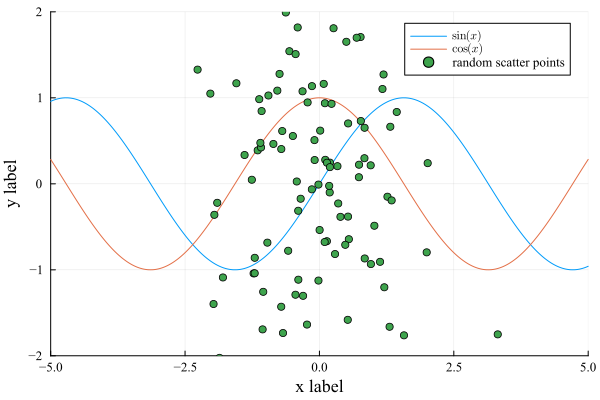

In [48]:
# 多次绘图
plot(x, sin.(x), label = L"\sin(x)", xlabel = "x label",
     ylabel = "y label", xlim = (-5,5), ylim = (-2, 2))
plot!(x, cos.(x), label = L"\cos(x)")
scatter!(randn(100), randn(100), label = "random scatter points", fontfamily="Times New Roman")

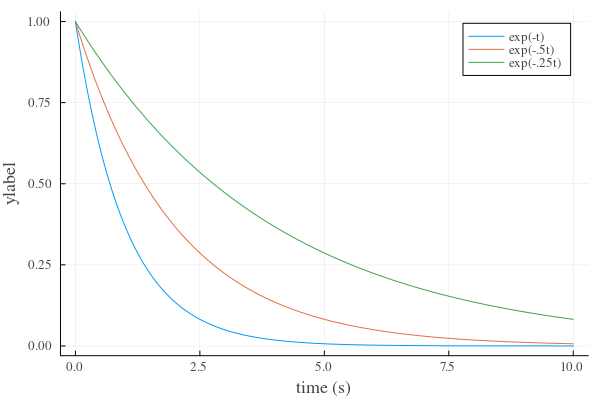

In [49]:
# trajectory: vector of vectors 
time_vec = 0:.01:10 

X = [[exp(-t), exp(-.5*t), exp(-.25*t)] for t in time_vec]

Xmatrix = hcat(X...)

# plot this (DONT FORGET THE TRANSPOSE)
plot(time_vec, Xmatrix', label = ["exp(-t)" "exp(-.5t)" "exp(-.25t)"],
     ylabel = "ylabel", xlabel = "time (s)", fontfamily="Times")

In [50]:
Pkg.add("ForwardDiff")

   Resolving package versions...
  No Changes to `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Project.toml`
  No Changes to `~/Documents/optimal-control/code/bilibili/lec0-julia_intro/Manifest.toml`


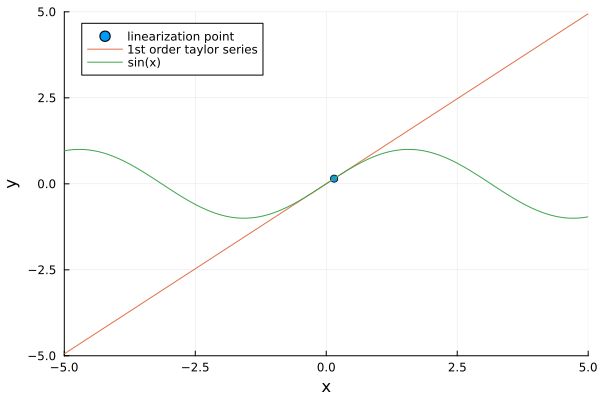

In [51]:
import ForwardDiff as FD

function first_order_taylor(f::Function, x̄::Float64, x::Float64)::Float64
    return f(x̄) + FD.derivative(f,x̄)*(x - x̄)
end

let 
    
    x = -6:.01:6
    y = sin.(x)
    
    # linearize about a random point 
    x̄ = randn()

    y_taylor = [first_order_taylor(sin, x̄, x_) for x_ in x]
    
    scatter([x̄], [sin(x̄)], label = "linearization point")
    plot!(x, y_taylor, label = "1st order taylor series")
    display(plot!(x,y, label = "sin(x)", xlabel = "x", ylabel = "y", xlim=[-5, 5], ylim=[-5, 5]))
    
end

In [52]:
# NamedTuples 
params = (a = 5, b = 6, c = 7)
@show params.c

params.c = 7


7

In [53]:
# we can't change these 
params.c = 5

LoadError: setfield!: immutable struct of type NamedTuple cannot be changed